# Procesamiento de Señales e Imágenes
**USACH - 2025-1**

**Profesor de cátedra:** Cristóbal Loyola

**Profesor ayudante:** Clemente Aguilar

# Semana 3
**Contenidos:**

- Gradiente de una imagen
- Convolución
- Ruido
    - Sal y pimienta
    - Impulso
    - Gaussiano
- Filtrado
    - Mediana
    - Promedio
    - Gaussiano
- Realce
- Detección de bordes
    - Roberts
    - Prewitt
    - Sobel
    - LoG
    - Canny



## Importar bibliotecas

In [63]:
import matplotlib.pyplot as plt
import numpy as np
import os
import cv2
from google.colab.patches import cv2_imshow

from skimage import data, filters, io, color, util, feature
from scipy import ndimage as ndi

# Únicamente para utilizar imágenes de Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Convolución

<div>
<center>
<img src="https://drive.google.com/uc?export=view&id=1nVFkY78SEAbS2NtNgKof7-9tnEddREXr" width="600"/>
</center>
</div>

In [64]:
# Definición de un filtro, kernel o máscara de convolución
kernel = np.array([[1, 0, -1],
                   [1, 0, -1],
                   [1, 0, -1]])

# ❓¿Qué pueden evidenciar de las dimensiones del filtro? ¿Por qué posee esa dimensión específica?

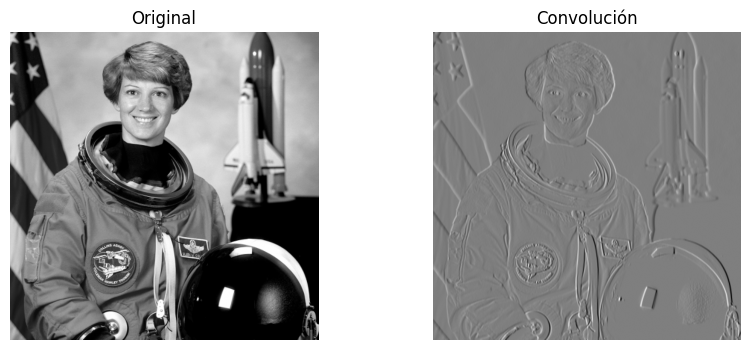

In [65]:
image = color.rgb2gray(data.astronaut())

convolved = ndi.convolve(image, kernel)

# Mostrar resultados
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray')
plt.title('Original')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(convolved, cmap='gray')
plt.title('Convolución')
plt.axis('off')
plt.show()


# Ruido
## 1. Sal y Pimienta

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

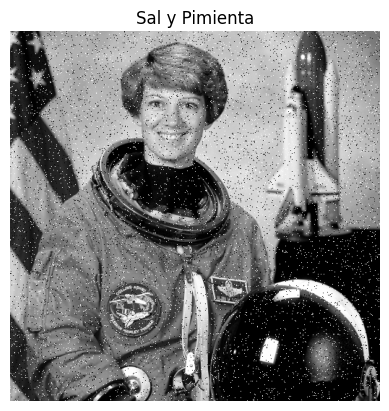

In [66]:
image_saltpepper = util.random_noise(image, mode='s&p', amount=0.05)

plt.imshow(image_saltpepper, cmap='gray')
plt.title('Sal y Pimienta')
plt.axis('off')

## 2. Impulso o Speckle

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

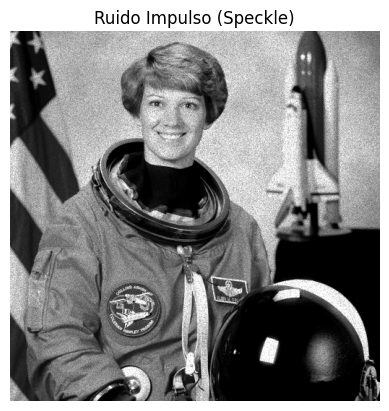

In [67]:
image_speckle = util.random_noise(image, mode='speckle')

plt.imshow(image_speckle, cmap='gray')
plt.title('Ruido Impulso (Speckle)')
plt.axis('off')

## 3. Gaussiano

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

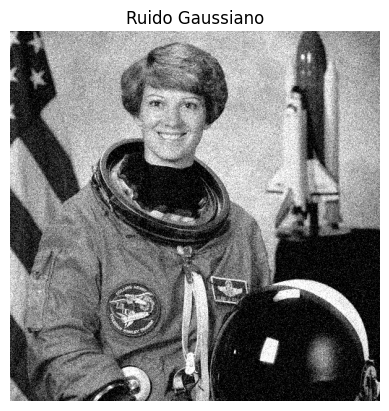

In [68]:
image_gauss_noise = util.random_noise(image, mode='gaussian', var=0.01)

plt.imshow(image_gauss_noise, cmap='gray')
plt.title('Ruido Gaussiano')
plt.axis('off')

# Filtrado de una imagen
## 1. Filtrado en base a kernel cualquiera

In [69]:
# Definición de un kernel. En este caso, por mi decisión de diseño de kernel,
# estoy realizando BOX FILTER
kernel_uniforme = np.ones((5, 5)) / 25

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

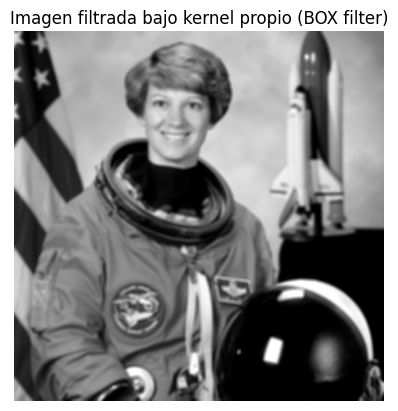

In [70]:
image_uniform = ndi.convolve(image, kernel_uniforme)
plt.imshow(image_uniform, cmap='gray')
plt.title('Imagen filtrada bajo kernel propio (BOX filter)')
plt.axis('off')

## 2. Filtro de mediana

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

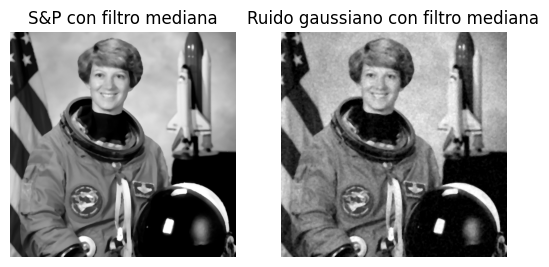

In [71]:
image_gauss_median = filters.median(image_gauss_noise, footprint=np.ones((5, 5)))
snp_median = filters.median(image_saltpepper, footprint=np.ones((5, 5)))

plt.subplot(1, 2, 1)
plt.imshow(snp_median, cmap='gray')
plt.title('S&P con filtro mediana')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(image_gauss_median, cmap='gray')
plt.title('Ruido gaussiano con filtro mediana')
plt.axis('off')

# ❓¿Por qué creen que ocurre este fenómeno con las imágenes con ruido S&P?

## 3. Filtro promedio

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

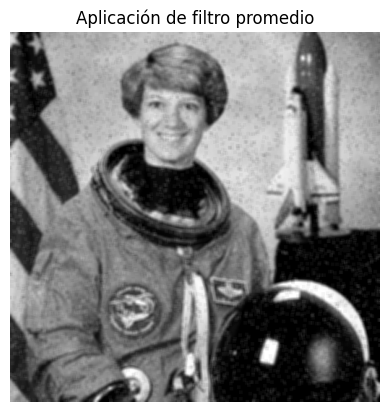

In [72]:
image_average = ndi.uniform_filter(image_saltpepper, size=5)

plt.imshow(image_average, cmap='gray')
plt.title('Aplicación de filtro promedio')
plt.axis('off')

## 2. Filtrado Gaussiano

<div>
<center>
<img src="https://drive.google.com/uc?export=view&id=1KorCgqpIemlELI230sq2f_13ToS6ShGj" width="500"/>
</center>
</div>

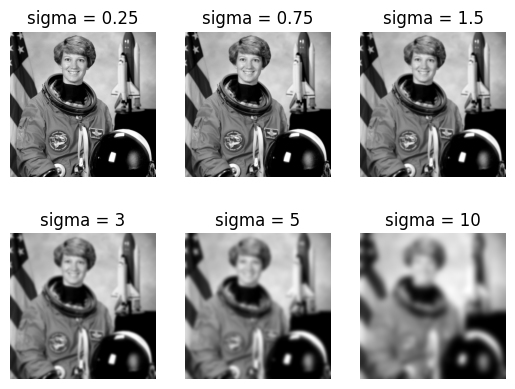

In [73]:
sigma_range = [0.25, 0.75, 1.5, 3, 5, 10]

for i in range(len(sigma_range)):
    image_gauss = filters.gaussian(image, sigma=sigma_range[i])
    plt.subplot(2, 3, i+1)
    plt.imshow(image_gauss, cmap='gray')
    plt.title(f'sigma = {sigma_range[i]}')
    plt.axis('off')

# ❓¿Qué es sigma? ¿Cómo impacta este parámetro al resultado final?

# Realce

In [74]:
sharp_kernel = np.array([[-1/3, -1/3, -1/3],
                           [-1/3, 5/2, -1/3],
                           [-1/3, -1/3, -1/3]])

# ❓¿Qué característica debe tener esta máscara o kernel para lograr realce?

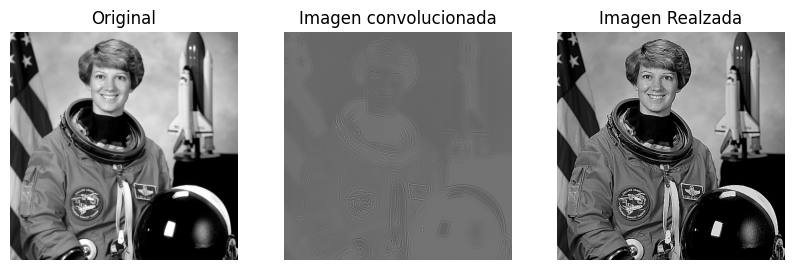

In [75]:
# Obtención de bordes mediante convolución con el kernel de realce
edges = ndi.convolve(image, sharp_kernel)
enhanced = image + edges

# Normalizar
enhanced = np.clip(enhanced, 0, 1)

plt.figure(figsize=(10, 4))
plt.subplot(1, 3, 1)
plt.imshow(image, cmap='gray')
plt.title('Original')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(edges, cmap='gray')
plt.title('Imagen convolucionada')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(enhanced, cmap='gray')
plt.title('Imagen Realzada')
plt.axis('off')
plt.show()

# Detección de bordes

# Gradiente de una imagen
❓De su bagaje académico, clases de cátedra de PSI y la imagen entregada: **¿Qué entienden por gradiente?**


<div>
<center>
<img src="https://drive.google.com/uc?export=view&id=1_V7wCDX5eGPTytBVEBz76VdLyFSDQl_n" width="600"/>
</center>
</div>

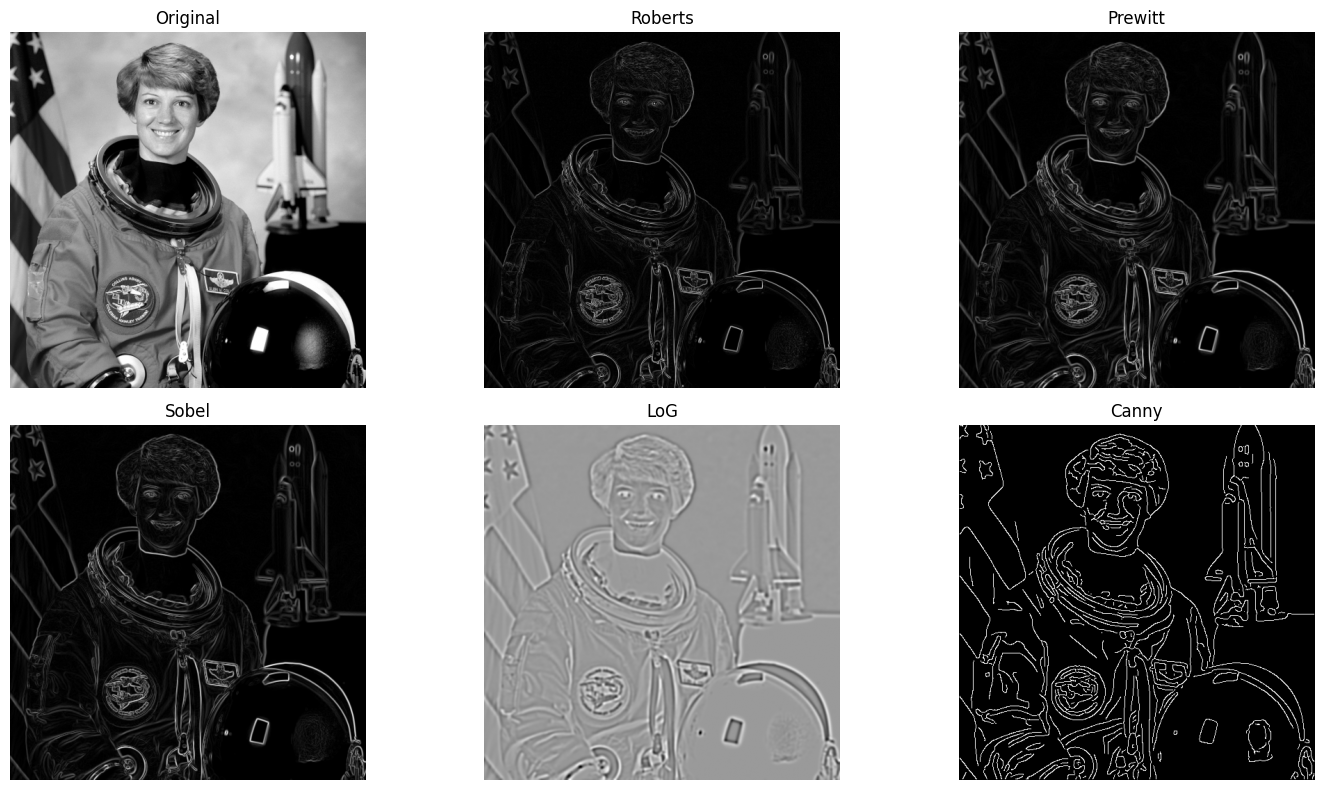

In [76]:
# Aplicar filtros
edges_roberts = filters.roberts(image)
edges_prewitt = filters.prewitt(image)
edges_sobel = filters.sobel(image)
edges_log = ndi.gaussian_laplace(image, sigma=2)
edges_canny = feature.canny(image, sigma=2)

# Mostrar resultados
plt.figure(figsize=(15, 8))

titles = ['Original', 'Roberts', 'Prewitt', 'Sobel', 'LoG', 'Canny']
images = [image, edges_roberts, edges_prewitt, edges_sobel, edges_log, edges_canny]

for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()